Alexander W. Criswell 2/14/26

Notebook to make the plot of $\Delta f_{\rm orphan}(e) / \Delta f_{\rm orphan, circ}$ for several example masses.

In [15]:
import numpy as np
from legwork import evol, utils
import astropy.units as u
import astropy.constants as const
from WaveformTools import Binary
from utils import set_style
import matplotlib.pyplot as plt
set_style()

Below is from the legwork tutorials

In [2]:
pulsar_times = (np.linspace(0.1,10)*u.kpc/const.c).to(u.yr)

In [3]:
pulsar_times

<Quantity [  326.15637772,   985.12538576,  1644.0943938 ,  2303.06340184,
            2962.03240988,  3621.00141792,  4279.97042596,  4938.939434  ,
            5597.90844204,  6256.87745008,  6915.84645812,  7574.81546616,
            8233.7844742 ,  8892.75348224,  9551.72249028, 10210.69149832,
           10869.66050636, 11528.6295144 , 12187.59852244, 12846.56753048,
           13505.53653852, 14164.50554656, 14823.4745546 , 15482.44356264,
           16141.41257068, 16800.38157872, 17459.35058676, 18118.3195948 ,
           18777.28860284, 19436.25761088, 20095.22661892, 20754.19562696,
           21413.164635  , 22072.13364304, 22731.10265108, 23390.07165912,
           24049.04066715, 24708.00967519, 25366.97868323, 26025.94769127,
           26684.91669931, 27343.88570735, 28002.85471539, 28661.82372343,
           29320.79273147, 29979.76173951, 30638.73074755, 31297.69975559,
           31956.66876363, 32615.63777167] yr>

## Estimating the enhancement effect

LEGWORK can only evolve the systems forward, not backward. It is therefore not feasible to set some conditions at merger and project back in time. Instead, we run a dense grid of initial eccentricities at some arbitrary reference frequency to get their eccentricity and frequency evolution. From there, we can lock all the evolution models to merge at t=0, then select those systems closest to the desired grid on eccentricity at the lookback time of the most distant pulsar and consider their frequency evolution with respect to the circular case.

In [85]:
ecc0_grid = [0.] + list(np.linspace(0.3,0.999,300))

In [86]:
maxdist_psr_dt = -pulsar_times[-1]

In [87]:
maxdist_psr_dt

<Quantity -32615.63777167 yr>

In [118]:
## set initial quantities
merge_pad = 10*u.yr
## set (arbitrary) reference frequencies from which to start evoluton
## these need to be different for different masses to avoid numerical instability/bounding
## (for example, we need WAY too many timesteps to evolve a m1=m2=1e7Msun system from 1 nHz)
frefs = {'1e9':{'fgw0':5e-10*u.Hz},
         '1e8':{'fgw0':1e-9*u.Hz},
         '1e7':{'fgw0':1e-8*u.Hz}}
for key in frefs.keys():
    frefs[key]['forb0'] = frefs[key]['fgw0']/2 

In [119]:
frefs

{'1e9': {'fgw0': <Quantity 5.e-10 Hz>, 'forb0': <Quantity 2.5e-10 Hz>},
 '1e8': {'fgw0': <Quantity 1.e-09 Hz>, 'forb0': <Quantity 5.e-10 Hz>},
 '1e7': {'fgw0': <Quantity 1.e-08 Hz>, 'forb0': <Quantity 5.e-09 Hz>}}

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.2658977943365D+16   r2 =                  NaN


/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.2583361758807D+16   r2 =                  NaN


/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


...

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4775041655767D+15   r2 =  0.2731109438298D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4775041655767D+15   r2 =  0.2731109438298D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4775041655767D+15   r2 =  0.2754278514296D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4775041655767D+15   r2 =  0.6885696285741D-02
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4415186588869D+15   r2 =  0.1336028780075D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4415186588869D+15   r2 =  0.1336028780075D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4415186588869D+15   r2 =  0.8537324524703D-02
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.4415186588869D+15   r2 =  0.2134331131176D-02
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


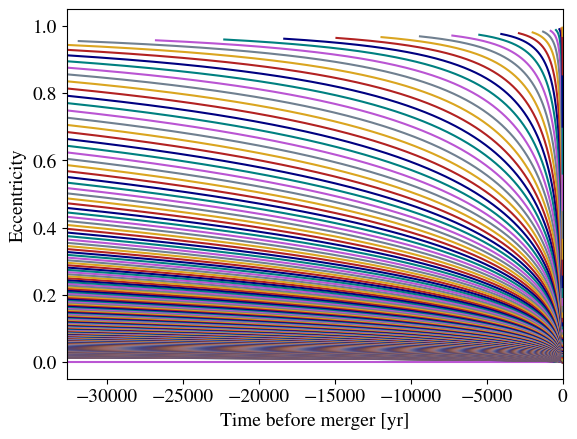

In [120]:
## mass 1e7
m_1 = m_2 = 1e7*u.Msun
plt.figure()
ecc_mdpsr_1e7 = np.empty(len(ecc0_grid))
fgw_mdpsr_1e7 = np.empty_like(ecc_mdpsr)
forb0 = frefs['1e7']['forb0']
fgw0 = frefs['1e7']['fgw0']
for i, ecc_i in enumerate(ecc0_grid):
    
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        ecc_mdpsr_1e7[i] = 0
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,
                                        small_e_tol=0.001,large_e_tol=0.999)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
        ecc_mdpsr_1e7[i] = ecc[np.argmin(np.abs((timesteps-t_merger) - maxdist_psr_dt))]
    fgw_mdpsr_1e7[i] = fgws[np.argmin(np.abs(((timesteps-t_merger) - maxdist_psr_dt)))].value
# plt.yscale('log')
plt.xlim(maxdist_psr_dt.value,0)
# plt.xlim(-200,0)
# plt.ylim(1e-8,1e-6)
# plt.legend()
plt.ylabel('Eccentricity')
plt.xlabel('Time before merger [yr]')
plt.show()

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2688879924754D+17   r2 =  0.1662311272121D+01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2688879924754D+17   r2 =  0.1662311272121D+01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2688879924754D+17   r2 =  0.1383171493956D+01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.2688879924754D+17   r2 =  0.3457928734889D+00
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.2382007950153D+17   r2 =                  NaN


/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


...

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1213571704773D+16   r2 =  0.5148226231825D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1213571704773D+16   r2 =  0.5148226231825D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1213571704773D+16   r2 =  0.5414952178312D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.1213571704773D+16   r2 =  0.1353738044578D-01
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.1056707173665D+16   r2 =                  NaN


/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.4425038712958D+15   r2 =                  NaN


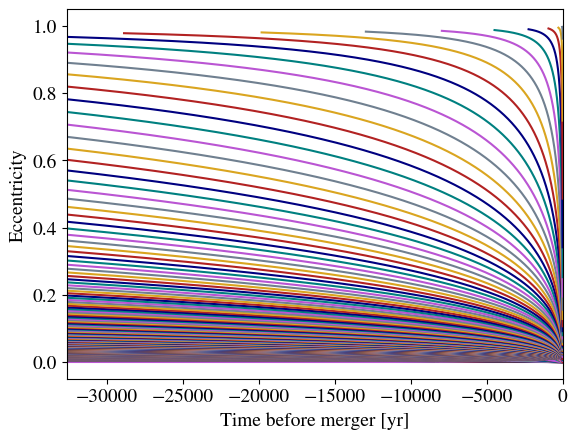

In [121]:
## mass 1e8
m_1 = m_2 = 1e8*u.Msun
plt.figure()
ecc_mdpsr_1e8 = np.empty(len(ecc0_grid))
fgw_mdpsr_1e8 = np.empty_like(ecc_mdpsr)
forb0 = frefs['1e8']['forb0']
fgw0 = frefs['1e8']['fgw0']
for i, ecc_i in enumerate(ecc0_grid):
    
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        ecc_mdpsr_1e8[i] = 0
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,
                                        small_e_tol=0.001,large_e_tol=0.999)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
        ecc_mdpsr_1e8[i] = ecc[np.argmin(np.abs((timesteps-t_merger) - maxdist_psr_dt))]
    fgw_mdpsr_1e8[i] = fgws[np.argmin(np.abs(((timesteps-t_merger) - maxdist_psr_dt)))].value
# plt.yscale('log')
plt.xlim(maxdist_psr_dt.value,0)
# plt.xlim(-200,0)
# plt.ylim(1e-8,1e-6)
# plt.legend()
plt.ylabel('Eccentricity')
plt.xlabel('Time before merger [yr]')
plt.show()

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.3616873499978D+16   r2 =                  NaN
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3596249014120D+16   r2 =  0.7828193131741D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3596249014120D+16   r2 =  0.7828193131741D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3596249014120D+16   r2 =  0.6870575522966D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t o

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3429040674098D+16   r2 =  0.7603082036914D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3429040674098D+16   r2 =  0.7603082036914D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3429040674098D+16   r2 =  0.6158430173291D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.3429040674098D+16   r2 =  0.1539607543323D-01
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()
/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


...

 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5454307759951D+15   r2 =  0.2556246348369D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5454307759951D+15   r2 =  0.2556246348369D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5454307759951D+15   r2 =  0.2166994270953D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5454307759951D+15   r2 =  0.5417485677381D-02
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5009755860073D+15   r2 =  0.2393643579974D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5009755860073D+15   r2 =  0.2393643579974D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5009755860073D+15   r2 =  0.2412166393429D-01
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.5009755860073D+15   r2 =  0.6030415983572D-02
 lsoda--  warning..internal t (=r1) 

/home/awc/.local/share/mamba/envs/gwenv-1/lib/python3.12/site-packages/legwork/evol.py:401: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  ecc_evol = np.array([odeint(de_dt, ecc_i[i], timesteps[i], args=(beta[i], c_0[i])).flatten()


 lsoda--  at t (=r1), too much accuracy requested    
       for precision of machine..  see tolsf (=r2)   
      in above,  r1 =  0.4690317007205D+15   r2 =                  NaN


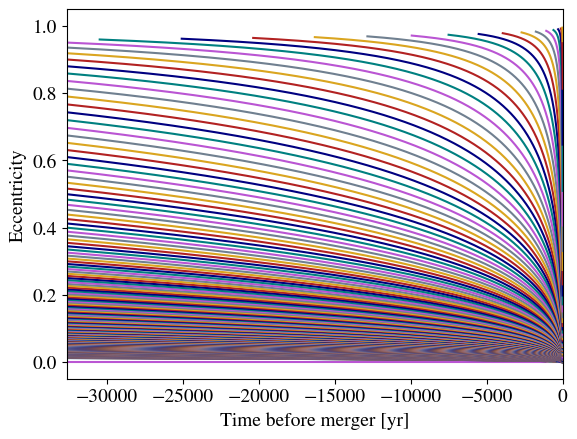

In [122]:
## mass 1e9
m_1 = m_2 = 1e9*u.Msun
plt.figure()
ecc_mdpsr_1e9 = np.empty(len(ecc0_grid))
fgw_mdpsr_1e9 = np.empty_like(ecc_mdpsr)
forb0 = frefs['1e9']['forb0']
fgw0 = frefs['1e9']['fgw0']
for i, ecc_i in enumerate(ecc0_grid):
    
    if ecc_i == 0:
        t_merger = evol.get_t_merge_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0)
        timesteps, fgws, a = evol.evol_circ(m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,
                                               output_vars=["timesteps","f_GW","a"])
        plt.plot(timesteps-t_merger,np.zeros(timesteps.size),label=str(ecc_i))
        ecc_mdpsr_1e9[i] = 0
    else:
        t_merger = evol.get_t_merge_ecc(ecc_i=ecc_i, m_1=m_1, m_2=m_2, f_orb_i=forb0,exact=True,
                                        small_e_tol=0.001,large_e_tol=0.999)
        timesteps, fgws, ecc, a = evol.evol_ecc(ecc_i,m_1=m_1, m_2=m_2, f_orb_i=forb0,n_step=100000,
                                                t_evol=t_merger-merge_pad,t_before=merge_pad,
                                               output_vars=["timesteps","f_GW","ecc","a"],exact_t_merge=True)
        plt.plot(timesteps-t_merger,ecc,label=str(ecc_i))
        ecc_mdpsr_1e9[i] = ecc[np.argmin(np.abs((timesteps-t_merger) - maxdist_psr_dt))]
    fgw_mdpsr_1e9[i] = fgws[np.argmin(np.abs(((timesteps-t_merger) - maxdist_psr_dt)))].value
# plt.yscale('log')
plt.xlim(maxdist_psr_dt.value,0)
# plt.xlim(-200,0)
# plt.ylim(1e-8,1e-6)
# plt.legend()
plt.ylabel('Eccentricity')
plt.xlabel('Time before merger [yr]')
plt.show()

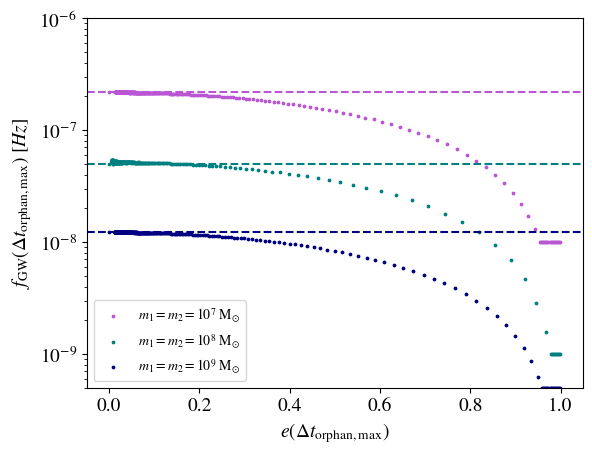

In [127]:
plt.figure()
plt.scatter(ecc_mdpsr_1e7,fgw_mdpsr_1e7,label=r'$m_1=m_2=10^7\ \mathrm{M}_{\odot}$',s=3)
plt.scatter(ecc_mdpsr_1e8,fgw_mdpsr_1e8,label=r'$m_1=m_2=10^8\ \mathrm{M}_{\odot}$',s=3)
plt.scatter(ecc_mdpsr_1e9,fgw_mdpsr_1e9,label=r'$m_1=m_2=10^9\ \mathrm{M}_{\odot}$',s=3)
plt.axhline(fgw_mdpsr_1e7[0],ls='--')
plt.axhline(fgw_mdpsr_1e8[0],ls='--',c='teal')
plt.axhline(fgw_mdpsr_1e9[0],ls='--',c='navy')
plt.yscale('log')
plt.ylabel(r"$f_{\rm GW}(\Delta t_{\rm orphan, max})\ [Hz]$")
plt.xlabel(r"$e(\Delta t_{\rm orphan, max})$")
plt.ylim(5e-10,1e-6)
plt.legend()
plt.show()

In [130]:
filt_1e7 = ecc_mdpsr_1e7 < 0.95
filt_1e8 = ecc_mdpsr_1e8 < 0.95
filt_1e9 = ecc_mdpsr_1e9 < 0.95

Frequency plot:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


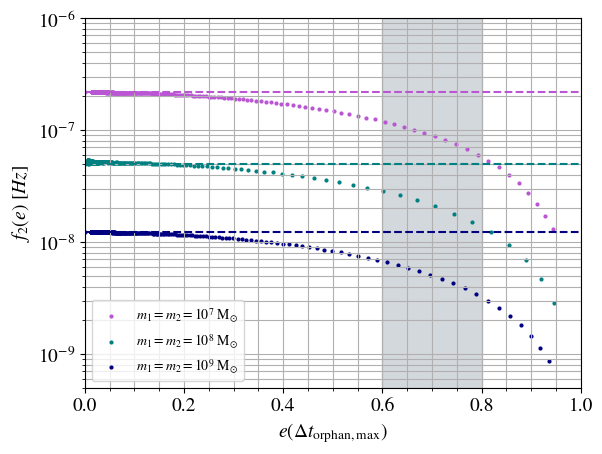

In [164]:
plt.figure()
plt.minorticks_on()
plt.grid(which='both')
plt.axvspan(0.6,0.8,color='slategrey',alpha=0.3)
plt.scatter(ecc_mdpsr_1e7[filt_1e7],fgw_mdpsr_1e7[filt_1e7],label=r'$m_1=m_2=10^7\ \mathrm{M}_{\odot}$',s=4)
plt.scatter(ecc_mdpsr_1e8[filt_1e8],fgw_mdpsr_1e8[filt_1e8],label=r'$m_1=m_2=10^8\ \mathrm{M}_{\odot}$',s=4)
plt.scatter(ecc_mdpsr_1e9[filt_1e9],fgw_mdpsr_1e9[filt_1e9],label=r'$m_1=m_2=10^9\ \mathrm{M}_{\odot}$',s=4)
plt.axhline(fgw_mdpsr_1e7[0],ls='--')
plt.axhline(fgw_mdpsr_1e8[0],ls='--',c='teal')
plt.axhline(fgw_mdpsr_1e9[0],ls='--',c='navy')
plt.yscale('log')
plt.ylabel(r"$f_{2}(e)\ [Hz]$")
plt.xlabel(r"$e(\Delta t_{\rm orphan, max})$")
plt.ylim(5e-10,1e-6)
plt.xlim(0,1)
plt.legend()
for ext in ['.png','.pdf','.eps']:
    plt.savefig('./figures/eccentricity/f2_of_e'+ext,dpi=300)
plt.show()

Really nice point to make here: eccentricities in the limiting region have the effect on $\Delta f$ of nearly a dex in total mass.

Relative shift plot:

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


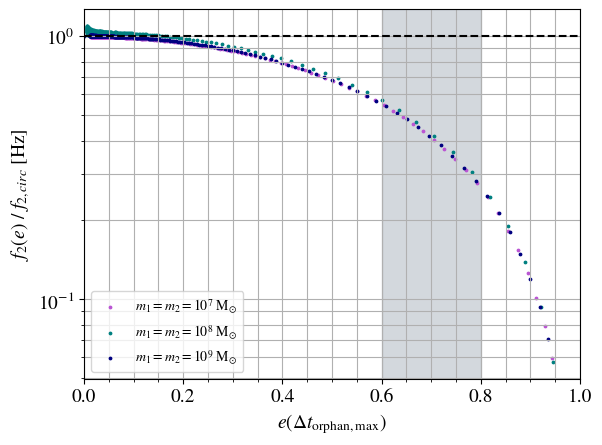

In [165]:
plt.figure()
plt.minorticks_on()
plt.grid(which='both')
plt.axvspan(0.6,0.8,color='slategrey',alpha=0.3)
plt.scatter(ecc_mdpsr_1e7[filt_1e7],fgw_mdpsr_1e7[filt_1e7]/fgw_mdpsr_1e7[0],
            label=r'$m_1=m_2=10^7\ \mathrm{M}_{\odot}$',s=3)
plt.scatter(ecc_mdpsr_1e8[filt_1e8],fgw_mdpsr_1e8[filt_1e8]/fgw_mdpsr_1e8[0],
            label=r'$m_1=m_2=10^8\ \mathrm{M}_{\odot}$',s=3)
plt.scatter(ecc_mdpsr_1e9[filt_1e9],fgw_mdpsr_1e9[filt_1e9]/fgw_mdpsr_1e9[0],
            label=r'$m_1=m_2=10^9\ \mathrm{M}_{\odot}$',s=3)
# plt.axhline(fgw_mdpsr_1e7[0],ls='--')
# plt.axhline(fgw_mdpsr_1e8[0],ls='--',c='teal')
# plt.axhline(fgw_mdpsr_1e9[0],ls='--',c='navy')
plt.axhline(1,ls='--',c='k')
plt.yscale('log')
plt.ylabel(r"$f_{2}(e)\ /\ f_{2, circ}$ [Hz]")
plt.xlabel(r"$e(\Delta t_{\rm orphan, max})$")
# plt.ylim(5e-10,1e-6)
plt.xlim(0,1)
plt.legend()
for ext in ['.png','.pdf','.eps']:
    plt.savefig('./figures/eccentricity/relative_f_of_e'+ext,dpi=300)
plt.show()

Note that the fuzz at low $e$ is due to error in the numerical integration; as we integrate from a set reference time to the merger time, this can translate to frequency error for slowly-evolving (i.e., nearly circular) sytems which are evolved much longer than the more quickly-evolving eccentric systems.